# General Information (All Reactors)

In [1]:
import flowtube

**Workflow For All Reactor Types**
---

1. Create an flow reactor object with dimensions and gases.
2. Create an experiment by definine flow rates, temperature, and pressure.
3. Upon initialization (steps 1 + 2), three tables will be outputed describing the experimental conditions:
   1. Flow rates and reactant concentrations.
   2. Fluid dynamics to check for laminar flow amongst other potentially important quanities.
   3. Reactant diffusion parameters including the temperature-dependent diffusion rate.
4. Determine the hypothetical loss rate and diffusion coefficient for a given uptake coefficient using the KPS method (see documentation for more information).
5. Fit experimental data assuming pseudo-first order kinetics to calculate an effective uptake coefficient.
6. Finally, using the diffusion correction factor, calculate the uptake coefficient.

**Supported Gases**
---

Carrier gases: Ar, He, N2, and O2.

Reactant gases: Ar, He, Air, Br2, Cl2, HBr, HCl, HI, H2O, I2, NO, N2, O2, and manual.

NOTE: the reactant diffusion coefficient must be manually inputted if the gas is manually inputted (see manual reactant gas example).

**Reactant Gas Sources**
---

Supported reactant gas sources include gas cylinders, permeation tubes, or sources that rely on saturation vapor pressure (e.g., temperature controlled cold trap containing a volatile species).

**Units**
---

All dimensions are in centimeters and all flow rates are in standard cubic centimeters per second (sccm).

Pressure units can be "Torr", "hPa", "mbar", "Pa", or "bar".

**Flows**
---
The gas flow through the flow tube is made up of a reactant gas flow through an injector and a carrier gas flow through the main flow tube. The reactant gas flow rate is made up of a main flow (reactant_FR) and a dilution flow (reactant_carrier_FR). If no reactant dilution flow is desired, set reactant_carrier_FR to 0 and input the total desired flow rate as reactant_FR.

# Coated Wall Reactor

**Reactor Dimensions and Gases**

Start by instantiating a coated wall reactor object by defining its dimensions and input gases

The use of an cylindrical insert placed inside of the flow tube is supported (see below).

In [2]:
### 1. Create Coated Wall Reactor (CWR) Object ###
# Flow tube inner diameter (cm)
FT_ID = 2.60

# Flow tube length (cm)
FT_length = 100

# Injector inner diameter (cm)
injector_ID = 1.05

# Injector outer diameter (cm)
injector_OD = 1.275

# Reactant gas (options: Ar, He, Air, Br2, Cl2, HBr, HCl, HI, H2O, I2, NO, N2, and O2)
reactant_gas = "HCl"

# Carrier gas (options: Ar, He, N2, and O2)
carrier_gas = "N2"

# Reactant concentration type (options: "ppm" or "ppb" for mixing ratio, "ng/min" for
# permeation rate, "Pa" or "hPa" or "Torr" or "mbar" or "mbar" for vapor pressure.
reactant_conc_type = "ppm"

# Reactant concentration value
reactant_conc=30

# If using a cylindrical insert, input the inner diameter and length of the insert. If 
# not using an insert, leave these parameters as their default value of None.
# Insert inner diameter (cm) - optional
insert_ID=1.89

# Insert length (cm) - optional
insert_length=20

cwr = flowtube.CoatedWallReactor(
    FT_ID = FT_ID,
    FT_length = FT_length,
    injector_ID = injector_ID,
    injector_OD = injector_OD,
    reactant_gas = reactant_gas,
    carrier_gas = carrier_gas,
    reactant_conc_type=reactant_conc_type,
    reactant_conc=reactant_conc,
    #insert_ID=insert_ID,
    #insert_length=insert_length,
)

**Experimental Conditions and Flow Rates**

Define experimental conditions including pressure, temperatures, and flow rates.

Can optionally input the axial and radial temperature gradients to check for convection-influenced transport.

In [3]:
### 2. Input Experimental Conditions ###
# Pressure (options: "Torr", "hPa", "mbar", "Pa", "bar")
P = 40
P_units = "Torr"

# Temperature (˚C)
T = 22


### Flow Setpoints ###
# Reactant Gas Flow Rate (sccm)
reactant_FR = 0.1

# Reactant Carrier Gas Flow Rate (sccm)
reactant_carrier_FR = 0

# Carrier Gas Flow Rate (sccm)
carrier_FR = 500

# Radial temperature gradient (C) - optional, default value is 1
radial_delta_T=1

# Axial temperature gradient along the flow tube (C) - optional, default value is 1
axial_delta_T=1

# Initialize the CWR object with the experimental conditions and flow setpoints
cwr.initialize(
    reactant_FR=reactant_FR,
    reactant_carrier_FR=reactant_carrier_FR,
    carrier_FR=carrier_FR,
    P=P,
    P_units=P_units,
    T=T,
    #axial_delta_T=axial_delta_T,
    #radial_delta_T=radial_delta_T
)

         Flow Setpoints and Conditions          
╒═════════════════════════════╤══════════╤═════════════╕
│ Reactant Flow Rate          │ 0.10     │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Reactant Carrier Flow Rate  │ 0.0      │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Total Reactant Flow Rate    │ 0.1      │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Minimum Carrier Flow Rate   │ 0.6      │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Carrier Flow Rate           │ 500.0    │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Total Flow Rate             │ 500.1    │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Injector HCl Concentration  │ 3e+04    │ ppb         │
├─────────────────────────────┼──────────┼─────────────┤
│ Flow Tube HCl Concentration │ 6        │ ppb         │
├─────────────────────────────┼────────

/Users/Corey/Desktop/Harvard/flowtube/flowtube/coated_wall_reactor.py:504: UserWarning: Axial buoyancy parameter > 1. Flow may be affected by buoyancy effects
  warnings.warn(


In [4]:
### 3. Calculate Reactant Gas Uptake and Diffusion Correction ###
# Define a hypothetical gamma value (or array of values) for the reactant gas uptake calculations
hypothetical_gamma=2e-4

cwr.reactant_uptake(hypothetical_gamma=hypothetical_gamma)

                         Reactant Uptake                         
╒═════════════════════════════════════════════════╤══════════╤══════════╕
│ Coated wall surface area (1/4 length)           │ 408.4    │ cm2      │
├─────────────────────────────────────────────────┼──────────┼──────────┤
│ Flow Tube Diffusion Correction Factor (γ_eff/γ) │ 0.69     │ unitless │
├─────────────────────────────────────────────────┼──────────┼──────────┤
│ Flow Tube Diffusion Correction                  │ 31.0     │ %        │
├─────────────────────────────────────────────────┼──────────┼──────────┤
│ Effective Uptake Coefficient                    │ 1.38e-04 │ unitless │
├─────────────────────────────────────────────────┼──────────┼──────────┤
│ Observed Loss Rate                              │ 2.2      │ s-1      │
├─────────────────────────────────────────────────┼──────────┼──────────┤
│ Flow Tube Loss - 1/4 Length                     │ 81.8     │ %        │
├─────────────────────────────────────────────

In [5]:
### 4. Fit Experimental Data to Extract Gamma ###
# If you have experimental data for the reactant gas uptake, you can fit the data to 
# extract the effective uptake coefficient. Example experimental data:

# Signal (arbitrary units)
signal=[0.95, 0.85, 0.7, 0.65, 0.5]

# Corresponding exposure values (can be in seconds or centimeters of injector travel)
# If using exposure in centimeters, the code will convert to cm of injector travel
# using the flow rate and reactor geometry. If using exposure in s, the code will use 
# the input values directly. NOTE: Exposure and signal should be anti-correlated so as 
# the injector is pulled upstream (increasing exposure), the signal decreases.
exposure=[1, 3, 5, 6, 9]
exposure_units="cm"

k, intercept, r_value, gamma, gamma_lower, gamma_upper = cwr.calculate_gamma(concentrations=signal, exposure=exposure, exposure_units=exposure_units)

# k is fitted first order rate constant (cm/s)
# intercept is the y-intercept of the fit
# r_value is the correlation coefficient for the fit
# gamma is the fitted uptake coefficient
# gamma_lower is the lower bound of the 95% confidence interval for gamma
# gamma_upper is the upper bound of the 95% confidence interval for gamma

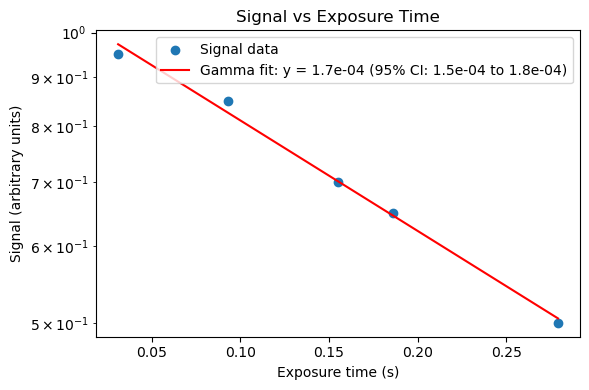

In [6]:
# It's a good idea to plot the data and the fit to visually inspect the quality of the 
# fit and the agreement between the data and the fitted curve.

import matplotlib.pyplot as plt
import numpy as np

# Convert exposure (cm) to time-like axis using flow velocity
x = np.array(exposure) / cwr.FT_flow_velocity
y = np.array(signal)

# Linear fit from previously fitted parameters
y_fit = np.exp(-k * x + intercept)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Signal data")
plt.plot(x, y_fit, color="red", label=f"Gamma fit: y = {gamma:.1e} (95% CI: {gamma_lower:.1e} to {gamma_upper:.1e})")
plt.xlabel("Exposure time (s)")
plt.ylabel("Signal (arbitrary units)")
plt.title("Signal vs Exposure Time")
plt.yscale("log")
plt.legend()
plt.tight_layout()

In [7]:
### 5. Correct for Diffusion ###
corrected_gamma = cwr.diffusion_corrected_uptake_coefficient(effective_gamma=gamma)
print(f"Diffusion-Corrected Gamma: {corrected_gamma:.2e}")

Diffusion-Corrected Gamma: 1.04e-04


# Boat Reactor

The Boat Reactor is analogous to the Coated Wall Reactor. The differences will be highlighted in this example. Please refer to the Coated Wall Reactor example for full usage.

The Boat Reactor lacks an analytical solution to the diffusion equations and thus, the hypothetical diffusion correction for the flow tube itself (i.e., the maximum diffusive distance) must be sufficiently small to ignore diffusion effects.

In [8]:
### 1. Create Boat Reactor Object ###

# Boat parameters
boat_liquid_width = 1.0 # width of the liquid in the boat (cm)
boat_length = 10.0 # length of the boat (cm)
boat_cross_section = 1.0 # cross-sectional area of the boat (cm^2)
boat_perimeter = 4.0 # perimeter of the boat (cm)

### Create Boat Reactor Object ###
boat = flowtube.BoatReactor(
    FT_ID = FT_ID,
    FT_length = FT_length,
    injector_ID = injector_ID,
    injector_OD = injector_OD,
    reactant_gas = reactant_gas,
    carrier_gas = carrier_gas,
    reactant_conc_type=reactant_conc_type,
    reactant_conc=reactant_conc,
    boat_liquid_width = boat_liquid_width,
    boat_length = boat_length,
    boat_cross_section = boat_cross_section,
    boat_perimeter = boat_perimeter,
)

In [9]:
### 2. Input Experimental Conditions ###
# Same behavior as CWR, but the outputs are different for some parameters

boat.initialize(
    reactant_FR=reactant_FR,
    reactant_carrier_FR=reactant_carrier_FR,
    carrier_FR=carrier_FR,
    P=P,
    P_units=P_units,
    T=T,
)

         Flow Setpoints and Conditions          
╒═════════════════════════════╤══════════╤═════════════╕
│ Reactant Flow Rate          │ 0.10     │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Reactant Carrier Flow Rate  │ 0.0      │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Total Reactant Flow Rate    │ 0.1      │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Minimum Carrier Flow Rate   │ 0.5      │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Carrier Flow Rate           │ 500.0    │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Total Flow Rate             │ 500.1    │ sccm        │
├─────────────────────────────┼──────────┼─────────────┤
│ Injector HCl Concentration  │ 3e+04    │ ppb         │
├─────────────────────────────┼──────────┼─────────────┤
│ Flow Tube HCl Concentration │ 6        │ ppb         │
├─────────────────────────────┼────────

/Users/Corey/Desktop/Harvard/flowtube/flowtube/boat_reactor.py:507: UserWarning: Axial buoyancy parameter > 1. Flow may be affected by buoyancy effects
  warnings.warn(


In [ ]:
### 3. Calculate Reactant Gas Uptake and Diffusion Correction ###
# Again, same behavior as CWR, but the outputs are different for some parameters
# A warning will be raised if the diffusion correction is greater than 5% because there 
# there is no diffusion correction for the boat reactor, so the uptake coefficient is 
# only valid if the diffusion correction is small.

boat.reactant_uptake(hypothetical_gamma=hypothetical_gamma)

                     Reactant Uptake                     
╒═════════════════════════════════════════════╤══════╤══════════╕
│ Boat Surface Area                           │ 10.0 │ cm2      │
├─────────────────────────────────────────────┼──────┼──────────┤
│ Flow Tube Wall Diffusion Correction         │ 31.0 │ %        │
│ (must be small to neglect for boat reactor) │      │          │
├─────────────────────────────────────────────┼──────┼──────────┤
│ Boat geometry correction factor             │ 6.63 │ unitless │
├─────────────────────────────────────────────┼──────┼──────────┤
│ Loss Rate                                   │ 0.48 │ s-1      │
├─────────────────────────────────────────────┼──────┼──────────┤
│ Loss to Boat - 1/4 Length                   │ 3.0  │ %        │
├─────────────────────────────────────────────┼──────┼──────────┤
│ Estimated Wall Loss (upper limit)           │ 2    │ %        │
╘═════════════════════════════════════════════╧══════╧══════════╛


/Users/Corey/Desktop/Harvard/flowtube/flowtube/boat_reactor.py:694: UserWarning: Diffusion correction is > 5%. Negligible diffusion may no longer be a valid assumption
  warnings.warn(


In [14]:
### 4. Fit Experimental Data to Extract Gamma ###
# Again, same behavior as CWR, but the outputs are different for some parameters

k, intercept, r_value, gamma, gamma_lower, gamma_upper = boat.calculate_gamma(concentrations=signal, exposure=exposure, exposure_units=exposure_units)

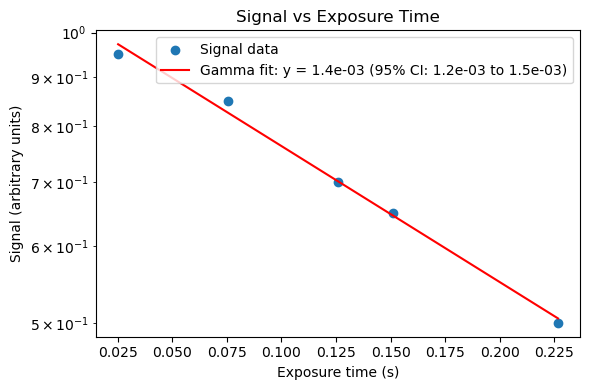

In [16]:
# It's a good idea to plot the data and the fit to visually inspect the quality of the 
# fit and the agreement between the data and the fitted curve.

import matplotlib.pyplot as plt
import numpy as np

# Convert exposure (cm) to time-like axis using flow velocity
x = np.array(exposure) / boat.flow_velocity
y = np.array(signal)

# Linear fit from previously fitted parameters
y_fit = np.exp(-k * x + intercept)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Signal data")
plt.plot(x, y_fit, color="red", label=f"Gamma fit: y = {gamma:.1e} (95% CI: {gamma_lower:.1e} to {gamma_upper:.1e})")
plt.xlabel("Exposure time (s)")
plt.ylabel("Signal (arbitrary units)")
plt.title("Signal vs Exposure Time")
plt.yscale("log")
plt.legend()
plt.tight_layout()

# Manual Reactant Gas

If a non-natively supported gas is inputted as reactant_gas, the diffusion coefficient (cm^2/s) must be inputted. If a natively supported gas is inputted, leave this parameter as its default value of None and the diffusion coefficient will be calculated based on the defined pressure and temperature values.

In [11]:
### Create Coated Wall Reactor (CWR) Object with a Manual Reactant Gas ###
# Manual reactant gas
reactant_gas = "ClONO2"

cwr = flowtube.CoatedWallReactor(
    FT_ID = 2.60,
    FT_length = 100,
    injector_ID = 1.05,
    injector_OD = 1.275,
    reactant_gas = reactant_gas,
    carrier_gas = "N2",
    reactant_conc_type="ppm",
    reactant_conc=30,
)

In [12]:
### Input Reactant Diffusion Coefficient ###
reactant_diffusion_rate = 2

cwr.initialize(
    reactant_FR=0.1,
    reactant_carrier_FR=0,
    carrier_FR=500,
    P=40,
    P_units="Torr",
    T=22,
    reactant_diffusion_rate=reactant_diffusion_rate,
)

           Flow Setpoints and Conditions           
╒════════════════════════════════╤══════════╤═════════════╕
│ Reactant Flow Rate             │ 0.10     │ sccm        │
├────────────────────────────────┼──────────┼─────────────┤
│ Reactant Carrier Flow Rate     │ 0.0      │ sccm        │
├────────────────────────────────┼──────────┼─────────────┤
│ Total Reactant Flow Rate       │ 0.1      │ sccm        │
├────────────────────────────────┼──────────┼─────────────┤
│ Minimum Carrier Flow Rate      │ 0.6      │ sccm        │
├────────────────────────────────┼──────────┼─────────────┤
│ Carrier Flow Rate              │ 500.0    │ sccm        │
├────────────────────────────────┼──────────┼─────────────┤
│ Total Flow Rate                │ 500.1    │ sccm        │
├────────────────────────────────┼──────────┼─────────────┤
│ Injector ClONO2 Concentration  │ 3e+04    │ ppb         │
├────────────────────────────────┼──────────┼─────────────┤
│ Flow Tube ClONO2 Concentration │ 6        │ pp

/Users/Corey/Desktop/Harvard/flowtube/flowtube/coated_wall_reactor.py:504: UserWarning: Axial buoyancy parameter > 1. Flow may be affected by buoyancy effects
  warnings.warn(
